# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [136]:
# DONE: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

# Your code here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [137]:
# DONE: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you
# Found air traffic dataset online (https://www.kaggle.com/datasets/yyxian/u-s-airline-traffic-data/data)
try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')

    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    
    # Clean the data by removing commas and converting to float
    for col in df.columns:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
    print("Creating sample air traffic data...")

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (249, 17)


## 2. Exploratory Data Analysis

In [138]:
# DONE: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
# Your code here:
display(df.info())

print("\nFirst 5 rows:")
# Your code here:
display(df.head())

print("\nBasic Statistics:")
# Your code here:
display(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    str    
 3   Int_Pax  249 non-null    str    
 4   Pax      249 non-null    str    
 5   Dom_Flt  249 non-null    str    
 6   Int_Flt  249 non-null    str    
 7   Flt      249 non-null    str    
 8   Dom_RPM  249 non-null    str    
 9   Int_RPM  249 non-null    str    
 10  RPM      249 non-null    str    
 11  Dom_ASM  249 non-null    str    
 12  Int_ASM  249 non-null    str    
 13  ASM      249 non-null    str    
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(3), int64(2), str(12)
memory usage: 33.2 KB


None


First 5 rows:


,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
0,2003,1,"43,032,450","4,905,830","47,938,280","785,160","57,667","842,827","36,211,422","12,885,980","49,097,402","56,191,300","17,968,572","74,159,872",64.44,71.71,66.20
1,2003,2,"41,166,780","4,245,366","45,412,146","690,351","51,259","741,610","34,148,439","10,715,468","44,863,907","50,088,434","15,587,880","65,676,314",68.18,68.74,68.31
2,2003,3,"49,992,700","5,008,613","55,001,313","797,194","58,926","856,120","41,774,564","12,567,068","54,341,633","57,592,901","17,753,174","75,346,075",72.53,70.79,72.12
3,2003,4,"47,033,260","4,345,444","51,378,704","766,260","55,005","821,265","39,465,980","10,370,592","49,836,572","54,639,679","15,528,761","70,168,440",72.23,66.78,71.02
4,2003,5,"49,152,352","4,610,834","53,763,186","789,397","55,265","844,662","41,001,934","11,575,026","52,576,960","55,349,897","15,629,821","70,979,718",74.08,74.06,74.07



Basic Statistics:


,Year,Month,Dom_LF,Int_LF,LF
count,249.000000,249.000000,249.000000,249.000000,249.000000
mean,2012.879518,6.445783,79.938394,77.304940,79.286305
std,6.002817,3.442803,8.860562,10.907145,8.895700
min,2003.000000,1.000000,13.090000,23.150000,13.830000
25%,2008.000000,3.000000,77.720000,76.430000,76.940000
50%,2013.000000,6.000000,82.120000,79.910000,81.580000
75%,2018.000000,9.000000,85.240000,82.930000,84.070000
max,2023.000000,12.000000,89.960000,89.440000,89.140000


In [139]:
# Dataset has many columns as strings with commas. Fixing:
def convert_all_to_numeric(df):
    for col in df.columns:
        # Check for both traditional 'object' and the newer 'string' or 'str' dtypes
        if str(df[col].dtype) in ('object', 'string', 'str'):
            try:
                # Remove commas (common in Pax data) and strip whitespace
                cleaned = df[col].astype(str).str.replace(',', '', regex=False).str.strip()
                
                # Attempt conversion; 'coerce' makes non-numbers (like names) into NaN
                temp_numeric = pd.to_numeric(cleaned, errors='coerce')

                # If at least some values successfully converted to numbers, update the column
                if not temp_numeric.isna().all():
                    # Check if they are whole numbers (to use Int64) or decimals (float)
                    # We use 'Int64' (capital I) because it allows integers to coexist with NaNs
                    if (temp_numeric % 1 == 0).all():
                        df[col] = temp_numeric.astype('Int64')
                    else:
                        df[col] = temp_numeric
            except Exception:
                continue
    return df

df = convert_all_to_numeric(df)

# Showing info again:
print("Dataset Info:")
# Your code here:
display(df.info())

print("\nFirst 5 rows:")
# Your code here:
display(df.head())

print("\nBasic Statistics:")
# Your code here:
display(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    Int64  
 3   Int_Pax  249 non-null    Int64  
 4   Pax      249 non-null    Int64  
 5   Dom_Flt  249 non-null    Int64  
 6   Int_Flt  249 non-null    Int64  
 7   Flt      249 non-null    Int64  
 8   Dom_RPM  249 non-null    Int64  
 9   Int_RPM  249 non-null    Int64  
 10  RPM      249 non-null    Int64  
 11  Dom_ASM  249 non-null    Int64  
 12  Int_ASM  249 non-null    Int64  
 13  ASM      249 non-null    Int64  
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: Int64(12), float64(3), int64(2)
memory usage: 36.1 KB


None


First 5 rows:


,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
0,2003,1,43032450,4905830,47938280,785160,57667,842827,36211422,12885980,49097402,56191300,17968572,74159872,64.44,71.71,66.20
1,2003,2,41166780,4245366,45412146,690351,51259,741610,34148439,10715468,44863907,50088434,15587880,65676314,68.18,68.74,68.31
2,2003,3,49992700,5008613,55001313,797194,58926,856120,41774564,12567068,54341633,57592901,17753174,75346075,72.53,70.79,72.12
3,2003,4,47033260,4345444,51378704,766260,55005,821265,39465980,10370592,49836572,54639679,15528761,70168440,72.23,66.78,71.02
4,2003,5,49152352,4610834,53763186,789397,55265,844662,41001934,11575026,52576960,55349897,15629821,70979718,74.08,74.06,74.07



Basic Statistics:


,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
count,249.000000,249.000000,249.0,249.0,249.0,249.0,249.0,249.0,249.0,249.0,249.0,249.0,249.0,249.0,249.000000,249.000000,249.000000
mean,2012.879518,6.445783,55209709.911647,7392209.437751,62601919.349398,706750.710843,64736.172691,771486.883534,49578034.168675,19181026.779116,68759060.963855,61318217.148594,24139025.365462,85457242.48996,79.938394,77.304940,79.286305
std,6.002817,3.442803,10440552.116201,2020273.174979,12292114.52498,107054.971522,12129.622461,115686.728629,10355583.119845,5711621.099062,15488747.284816,8996673.009788,5650437.150676,13823850.68201,8.860562,10.907145,8.895700
min,2003.000000,1.000000,2877290.0,136609.0,3013899.0,217262.0,4996.0,222280.0,2551127.0,356762.0,2907889.0,19489079.0,1541419.0,21030499.0,13.090000,23.150000,13.830000
25%,2008.000000,3.000000,50982170.0,6395022.0,57664576.0,662000.0,61615.0,727898.0,44580290.0,16602844.0,61825679.0,56555517.0,21731193.0,79197800.0,77.720000,76.430000,76.940000
50%,2013.000000,6.000000,56200104.0,7419187.0,63899130.0,709933.0,66557.0,779011.0,49857937.0,19689006.0,69005186.0,60889086.0,24645715.0,85051909.0,82.120000,79.910000,81.580000
75%,2018.000000,9.000000,60892131.0,8567847.0,69447429.0,781804.0,71924.0,848650.0,55682567.0,22667597.0,78039874.0,66268767.0,27705349.0,92551868.0,85.240000,82.930000,84.070000
max,2023.000000,12.000000,75378157.0,12432615.0,87810772.0,890938.0,82681.0,964102.0,72267904.0,31376000.0,103643904.0,81997399.0,35326191.0,117312202.0,89.960000,89.440000,89.140000


In [140]:
# DONE: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
# Your code here:
print(df.isnull().sum())

# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # N/A: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

print(f'No missing values.')

Missing values:
Year       0
Month      0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_RPM    0
Int_RPM    0
RPM        0
Dom_ASM    0
Int_ASM    0
ASM        0
Dom_LF     0
Int_LF     0
LF         0
dtype: int64
No missing values.


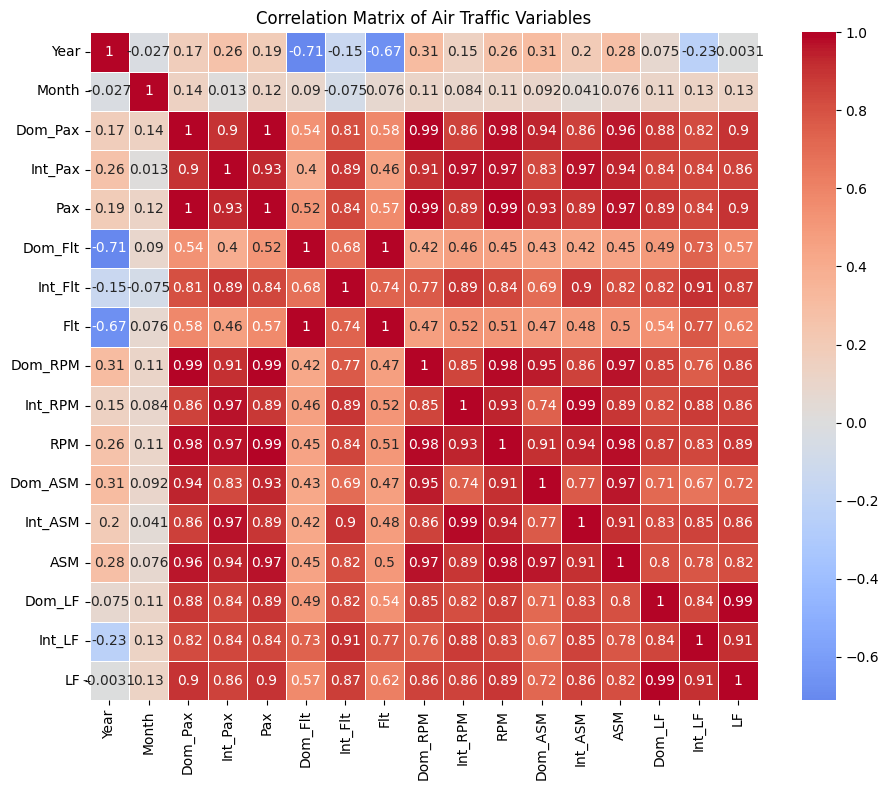

Strongest correlations:
Dom_Pax  Pax        0.997455
Dom_Flt  Flt        0.997068
Dom_LF   LF         0.989608
Pax      Dom_RPM    0.989246
         RPM        0.988162
Dom_Pax  Dom_RPM    0.988025
Int_RPM  Int_ASM    0.985573
Dom_RPM  RPM        0.980444
RPM      ASM        0.976904
Dom_Pax  RPM        0.976018
Int_Pax  Int_ASM    0.972737
Dom_RPM  ASM        0.972228
Int_Pax  Int_RPM    0.970857
Pax      ASM        0.970572
Int_Pax  RPM        0.968397
Dom_ASM  ASM        0.965322
Dom_Pax  ASM        0.961377
Dom_RPM  Dom_ASM    0.954935
dtype: float64


In [141]:
# DONE: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr() 

# Create heatmap:
# DONE: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)


plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# DONE: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Your analysis here:

# 1. Create a mask for the upper triangle (including the diagonal)
# np.triu returns the upper triangle; np.ones_like creates a matrix of 1s the same size
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 2. Apply the mask to the matrix (setting the upper half to NaN)
lower_matrix = correlation_matrix.mask(mask)

# 3. Unstack and filter
sol = lower_matrix.unstack()
high_corr = sol[(sol > 0.95) & (sol < 1.0)]

print(high_corr.sort_values(ascending=False))



## 3. Hypothesis Testing

In [142]:
# DONE: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'],df['Int_Pax'])
# DONE: Complete this line using stats.ttest_ind()

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# DONE: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# DONE: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # DONE: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("The mean of domestic passengers is different to a statistically significant degree from the mean of international passengers.")
else:
    # DONE: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("The mean of domestic passengers is notdifferent to a statistically significant degree from the mean of international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 70.9547
P-value: 0.000000
Mean Domestic Passengers: 55209710
Mean International Passengers: 7392209

Conclusion: Reject H0 (p < 0.05)
The mean of domestic passengers is different to a statistically significant degree from the mean of international passengers.


In [143]:
# DONE: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Flt'], df['Pax'])
# DONE: Complete this line using stats.pearsonr()

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# DONE: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # DONE: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("As total flights increase, total passengers increase.")# DONE: What does positive correlation mean?
    else:
        print("As total flights increase, total passengers decrease.") # DONE: What does negative correlation mean?
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is not a significant corelation between total passengers and total flights.")# DONE: Add your interpretation here


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.5698
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
As total flights increase, total passengers increase.


## 4. Simple Linear Regression

In [144]:
# DONE: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]
# DONE: Select the feature column (Total Flights)
y_simple = df['Pax']
# DONE: Select the target column (Total Passengers)

# Split the data:
# DONE: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
# DONE: Create LinearRegression instance
# DONE: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)
# DONE: Predict on test data

# DONE: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple) # DONE: Calculate R² score
mse_simple = mean_squared_error(y_test_simple, y_pred_simple) # DONE: Calculate MSE
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple) # DONE: Calculate MAE
rmse_simple = np.sqrt(mse_simple) # DONE: Calculate RMSE (square root of MSE)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: -0.0092
Mean Squared Error: 110855922051702.88
Root Mean Squared Error: 10528813.90
Mean Absolute Error: 9262992.73

Model Equation: Passengers = 13253573.91 + 63.71 × Flights


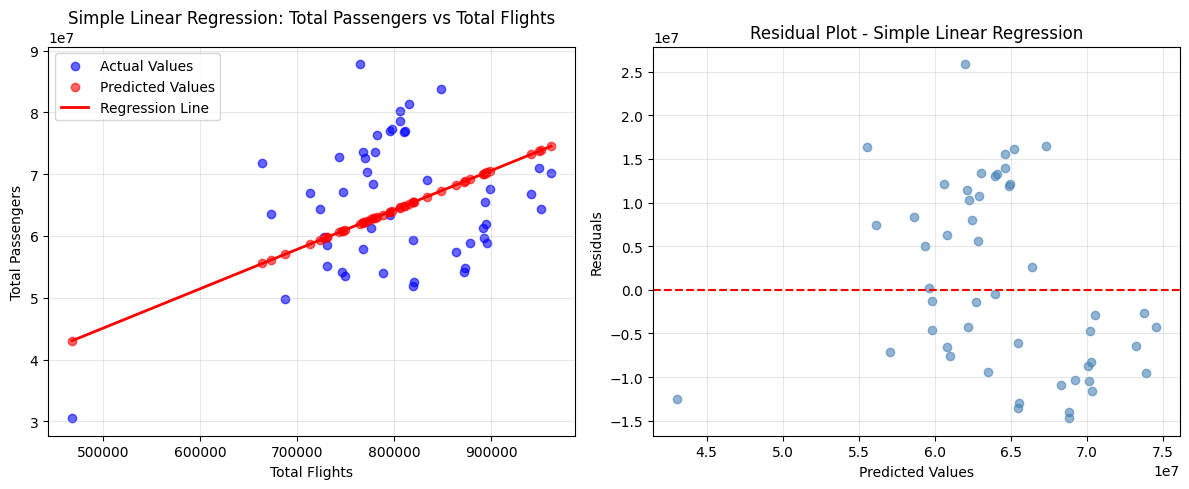

In [145]:
# DONE: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# DONE: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
# 1. Scatter actual values
plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Values', alpha=0.6)

# 2. Scatter predicted values
plt.scatter(X_test_simple, y_pred_simple, color='red', label='Predicted Values', alpha=0.6)

# 3. Plot a line through the predicted values
# Note: If X_test is not sorted, the line will jump around. 
# We sort by X to ensure the line is continuous.
sorted_idx = X_test_simple.values.flatten().argsort()
plt.plot(X_test_simple.iloc[sorted_idx], y_pred_simple[sorted_idx], color='red', linewidth=2, label='Regression Line')



plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# DONE: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple
# DONE: Calculate residuals

# DONE: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [146]:
# DONE: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# DONE: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_RPM', 'Int_RPM', 'Dom_ASM', 'Int_ASM'] # DONE: List of feature column names
#Avoided Dom_Pax and Int_Pax because they simply add up to Pax and would be multicollinearity.
X_multiple = df[feature_columns] # DONE: Select features from dataframe
y_multiple = df['Pax'] # DONE: Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# DONE: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple,  test_size=0.2, random_state=42)

# DONE: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler() # DONE: Create StandardScaler instance
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
# DONE: Fit and transform training data
X_test_mult_scaled = scaler.transform(X_test_mult)
# DONE: Transform test data (don't fit again!)

# DONE: Create and train the multiple regression model
multiple_model = LinearRegression() # DONE: Create LinearRegression instance
# DONE: Fit the model
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# DONE: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)
# DONE: Predict on scaled test data

# DONE: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult) # DONE: Calculate R² score
mse_mult = mean_squared_error(y_test_mult, y_pred_mult) # DONE: Calculate MSE
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult) # DONE: Calculate MAE
rmse_mult = np.sqrt(mse_mult) # DONE: Calculate RMSE

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# DONE: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Flt', 'Int_Flt', 'Dom_RPM', 'Int_RPM', 'Dom_ASM', 'Int_ASM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.9969
Mean Squared Error: 342823762039.52
Root Mean Squared Error: 585511.54
Mean Absolute Error: 436367.41

Feature Coefficients (after scaling):
Dom_Flt: 1637002.8289
Int_Flt: -201002.2756
Dom_RPM: 11963147.3124
Int_RPM: 152176.7269
Dom_ASM: -1523150.3266
Int_ASM: 1393634.1879
Intercept: 61921705.70


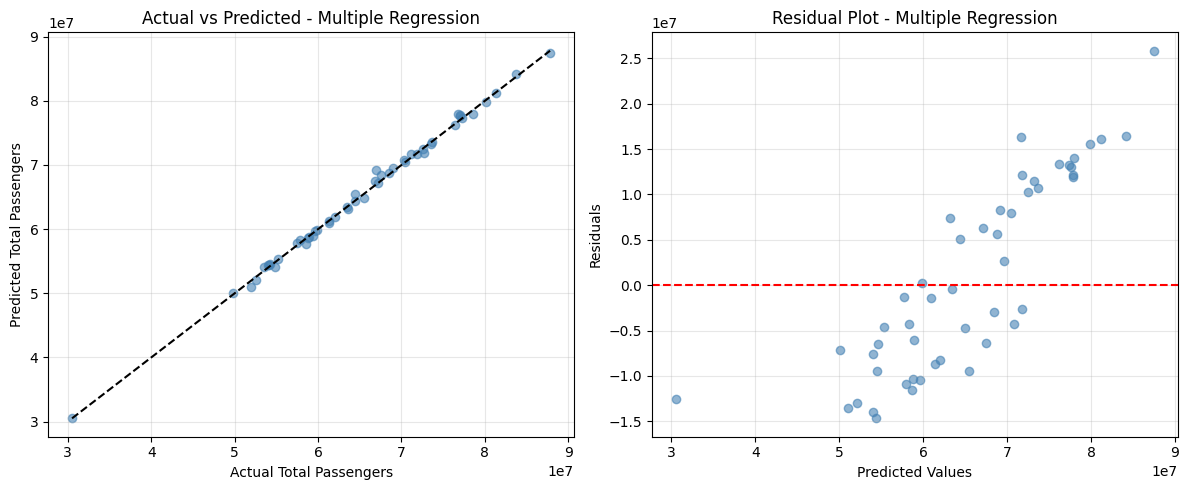

In [147]:
# DONE: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# DONE: Create scatter plot of actual vs predicted values
# DONE: Add a diagonal reference line (perfect prediction line)
plt.scatter(y_test_mult, y_pred_mult, alpha=0.6, color='steelblue')
low = min(y_test_mult.min(), y_pred_mult.min())
high = max(y_test_mult.max(), y_pred_mult.max())
plt.plot([low, high], [low, high], color='black', linestyle='--', label='Perfect Prediction (y=x)')

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# DONE: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult # DONE: Calculate residuals


# DONE: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals, alpha=0.6, color='steelblue')

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [148]:
# DONE: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# DONE: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections

print(f"{'R² Score:':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Mean Squared Error:':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")
print(f"{'Root Mean Squared Error:':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error:':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# DONE: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = r2_mult - r2_simple # DONE: Calculate percentage improvement
else:
    better_model = "Simple Regression"
    improvement = r2_simple - r2_mult # DONE: Calculate percentage improvement

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement*100:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score:                 -0.0092              0.9969              
Mean Squared Error:       110855922051702.88   342823762039.52     
Root Mean Squared Error:  10528813.90          585511.54           
Mean Absolute Error:      9262992.73           436367.41           

Best Model: Multiple Regression
R² Improvement: 100.61%


## 7. Statistical Insights and Conclusions

In [149]:
# DONE: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# DONE: Summarize your hypothesis test results
print(f"   • Domestic vs International Passengers: There is a statistically significant difference between the means of these groups.")
print(f"""   • Correlation between Total Passengers and Flights: They are significantly positively correlated:
        As total flights increase, total passengers increase.""")

print("\n2. REGRESSION ANALYSIS:")
# DONE: Summarize regression model performance
print(f"   • Simple Linear Regression R²: -0.0092. This regression explained less than 0% of variance, worse than the mean.")
print(f"   • Multiple Linear Regression R²: 0.9969. This regression explained 99.69% of variance.")
print(f"   • Best performing model: Multiple Linear Regression")

print("\n3. KEY FINDINGS:")
# DONE: Identify and discuss key findings from your analysis
print(f"   • Although total flights and total passengers are correlated, a linear model between them can't predict well.")
print(f"   • Total passengers can be predicted well by various flight characteristics.")
print(f"   • International and domestic flight data affect total passenger amounts very differently.")

print("\n4. RECOMMENDATIONS:")
# DONE: Provide practical recommendations based on your analysis
print("   • Use flight data to predict total passengers expected and help airports accomodate expected demand.")
print("   • Use flight data to predict total passengers expected and help airlines prepare for expected gas costs.")
print("   • Use flight data to look at trends in total flights over time and help the FAA prepare flight route capacity.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: There is a statistically significant difference between the means of these groups.
   • Correlation between Total Passengers and Flights: They are significantly positively correlated:
        As total flights increase, total passengers increase.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: -0.0092. This regression explained less than 0% of variance, worse than the mean.
   • Multiple Linear Regression R²: 0.9969. This regression explained 99.69% of variance.
   • Best performing model: Multiple Linear Regression

3. KEY FINDINGS:
   • Although total flights and total passengers are correlated, a linear model between them can't predict well.
   • Total passengers can be predicted well by various flight characteristics.
   • International and domestic flight data affect total passenger amounts very differently.

4. RECOMMENDATIONS:
   • Use flight data to predict 

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

The results tell me there was a difference between the numbers of domestic and international flights, and that there was a positive correlation between total passengers and flights. Both of these were expected and make sense.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

The multiple linear regression model performed better. The R² value tells me the regression explained 99.69% of variance.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

The strongest correlations were actually between variables where one was used to calculate another (such as Dom_Pax and Pax, where Pax = Dom_Pax + Int_Pax). An interesting strong correlation that did not fit this situation is the correlation between RPM (revenue passenger miles) and ASM (available seat miles). Here we can conclude that the amount of seats available and the amount of seats taken (passengers) correlated, which makes sense: as more seats are available, more passengers use them, or conversely, as more passengers fly, more flight seats are made available for them.


4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

Both residual plots seem to indicate correlated patterns. This suggests there may be additional patterns the models have not captured and the potential to improve the models, even though the multiple linear regression model got such a high R².

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

In real-world scenarios, airlines might be able to use these statistical models in the following ways: They could use flight data to predict total passengers expected and help airports accomodate expected demand, and  prepare for expected gas costs. THey could also use flight data to look at trends in total flights over time and help the FAA prepare flight route capacity.